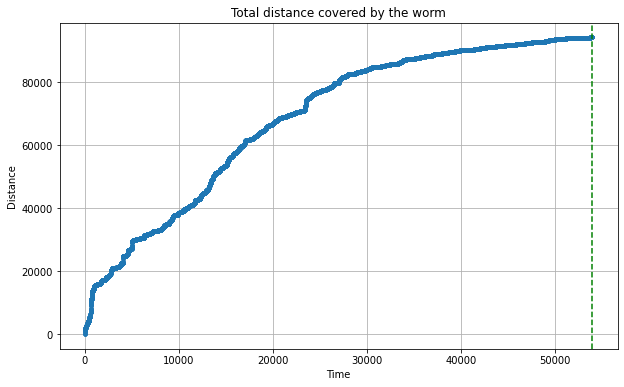

KeyboardInterrupt: 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifespan_functions import wormstats

def adjust_lifespan(lifespan, csv_file_path):
    data = pd.read_csv(csv_file_path)
    n = data.index + 1
    data['Time elapsed (in sec)'] = 2 * n + np.floor((n - 1) / 900) * 5.5 * 3600
    data['Time elapsed (in hours)'] = data['Time elapsed (in sec)']/3600
    lifespan = data[data['Time elapsed (in hours)'] == lifespan].index

    decide = 'Y'
    while decide in ('Y', 'y'):
        # plt.figure(figsize=(10, 6))
        # plt.plot(data.index, data['Changed Pixels'], marker='.', linestyle='')
        # plt.title("Change in pixels as a function of time")
        # plt.xlabel("Time")
        # plt.ylabel("Change in pixels")
        # plt.axhline(y=data['Changed Pixels'].mean(), color='red', linestyle='--', label='Mean of changed pixels')
        # plt.axvline(x=lifespan, color='green', linestyle='--' )
        # plt.grid(True)
        # plt.legend()
        # plt.show()
    
        # plt.figure(figsize=(10, 6))
        # plt.plot(data.loc[data.Speed<100].index, data.loc[data.Speed<100]['Speed'], marker='.', linestyle='')
        # plt.title("Change in speed as a function of time")
        # plt.xlabel("Time")
        # plt.ylabel("Speed")
        # plt.axhline(y=data['Speed'].mean(), color='red', linestyle='--', label='Mean of changed pixels')
        # plt.axvline(x=lifespan, color='green', linestyle='--' )
        # plt.grid(True)
        # plt.legend()
        # plt.show()
    
        data['Instantaneous Distance'] = np.sqrt(
            (data['X'].diff() ** 2) + (data['Y'].diff() ** 2)
        ).fillna(0)
        data['Total Distance'] = data['Instantaneous Distance'].cumsum()
        plt.figure(figsize=(10, 6))
        plt.plot(data.index, data['Total Distance'], marker='.', linestyle='')
        plt.title("Total distance covered by the worm")
        plt.xlabel("Time")
        plt.ylabel("Distance")
        plt.axvline(x=lifespan, color='green', linestyle='--' )
        plt.grid(True)
        plt.show()

        decide = input('Do you want to manually fix lifespan? Y/N')
        if decide not in ('Y', 'y', 'N', 'n'):
            decide = input('Do you want to manually fix lifespan? Y/N')
        elif decide in ('Y', 'y'):
            while True:
                try:
                    new_idx = int(input(f'Enter new index (0 to {len(data) - 1}): ').strip())
                    if 0 <= new_idx < len(data):
                        lifespan = new_idx
                        break
                    else:
                        print(f"Index out of bounds! Please enter a number between 0 and {len(data) - 1}.")
                except ValueError:
                    print("Invalid input! Please enter an integer.")
        elif decide in ('N', 'n'):
            if isinstance(lifespan, pd.Int64Index):  # If lifespan is an Int64Index
                lifespan_idx = lifespan[0]  # Extract the scalar index
            else:
                lifespan_idx = lifespan  # If lifespan is already an integer
            print(lifespan, data['Time elapsed (in hours)'].iloc[lifespan_idx])
            return data['Time elapsed (in hours)'].iloc[lifespan_idx]
        else:
            decide == 'Y'
    # return data['Time elapsed (in hours)'].iloc[lifespan]
    
all_data = []

for x in range(1, 13):
    csv_file_path = f'../Lifespan2/companyDrug/companyDrug{x}.csv'  
    y = wormstats(csv_file_path) 
    lifespan = y.loc[0,'lifespan']
    y['lifespan']= adjust_lifespan(lifespan, csv_file_path)
    y['drugged'] = 1            
    y['worm_id'] = x             
    all_data.append(y)           

for x in range(1, 13):
    csv_file_path = f'../Lifespan2/controlTerbinafin/controlTerbinafin{x}.csv' 
    y = wormstats(csv_file_path) 
    lifespan = y.loc[0,'lifespan']
    y['lifespan']= adjust_lifespan(lifespan, csv_file_path)
    y['drugged'] = 0            
    y['worm_id'] = x+12            
    all_data.append(y)       

for x in range(1, 13):
    csv_file_path = f'../Lifespan2/Terbinafin/Terbinafin{x}.csv' 
    y = wormstats(csv_file_path) 
    lifespan = y.loc[0,'lifespan']
    y['lifespan']= adjust_lifespan(lifespan, csv_file_path)
    y['drugged'] = 2            
    y['worm_id'] = x+24             
    all_data.append(y)         

for x in range(1, 13):
    csv_file_path = f'../Lifespan2/control/control{x}.csv'  
    y = wormstats(csv_file_path)  
    lifespan = y.loc[0,'lifespan']
    y['lifespan']= adjust_lifespan(lifespan, csv_file_path)
    y['drugged'] = 0            
    y['worm_id'] = x+36          
    all_data.append(y)        

merged_df = pd.concat(all_data, axis=0, ignore_index=True)
merged_df

In [3]:
merged_df.to_csv('../lifespan_merged_datasets/mergedworms_final.csv')

In [ ]:
import matplotlib as plt

plt.figure(figsize=(10, 6))
plt.plot(merged_df, data['Changed Pixels'], marker='.', linestyle='')
plt.title("Change in pixels as a function of time")
plt.xlabel("Time")
plt.ylabel("Change in pixels")
plt.axhline(y=data['Changed Pixels'].mean(), color='red', linestyle='--', label='Mean of changed pixels')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# 35000 64750 54200 60500